#   SMS Spam Detection using RNN, LSTM, and Glove Embedding
# Name: Luna Maharjan
# Student Id: 2418109

## Step 1: Install Dependencies

In [1]:
# Install required libraries
!pip install contractions wordcloud
!pip install numpy==1.23.5
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 50.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.9 MB/s eta 0:00:00


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Step 3: Mount Google Drive and Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv(
    '/content/drive/MyDrive/spamvsham.csv',
    encoding='latin-1'
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Keep only relevant columns and rename
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Encode labels: ham=0, spam=1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Step 4: Dataset Information and Analysis

In [6]:
print("Dataset Shape:", df.shape)
print("\nNull Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['label'].value_counts())
print("\nClass Distribution (%)")
print(df['label'].value_counts(normalize=True) * 100)

Dataset Shape: (5572, 2)

Null Values:
label      0
message    0
dtype: int64

Class Distribution:
label
0    4825
1     747
Name: count, dtype: int64

Class Distribution (%)
label
0    86.593683
1    13.406317
Name: proportion, dtype: float64


## Step 5: Visualizations

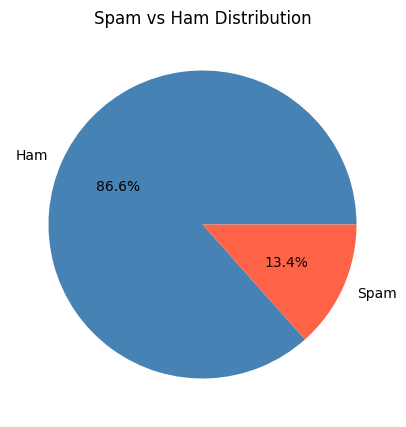

In [7]:
# Pie Chart - Class Distribution
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham', 'Spam'],
    figsize=(5, 5),
    colors=['steelblue', 'tomato']
)
plt.title("Spam vs Ham Distribution")
plt.ylabel('')
plt.show()

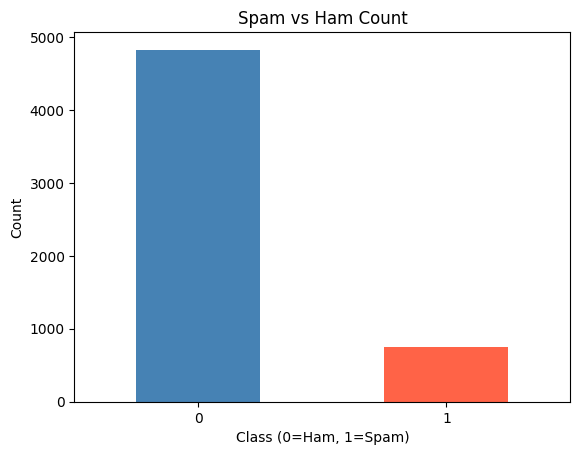

In [8]:
# Bar Chart - Class Distribution
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Spam vs Ham Count")
plt.xlabel("Class (0=Ham, 1=Spam)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Step 6: Text Preprocessing and Cleaning

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Handle contractions: don't -> do not
    text = contractions.fix(text)
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (#tag)
    text = re.sub(r'#\w+', '', text)
    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)
    # Tokenize, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_message'] = df['message'].apply(clean_text)

df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


## Step 7: Word Cloud and Most Common Words

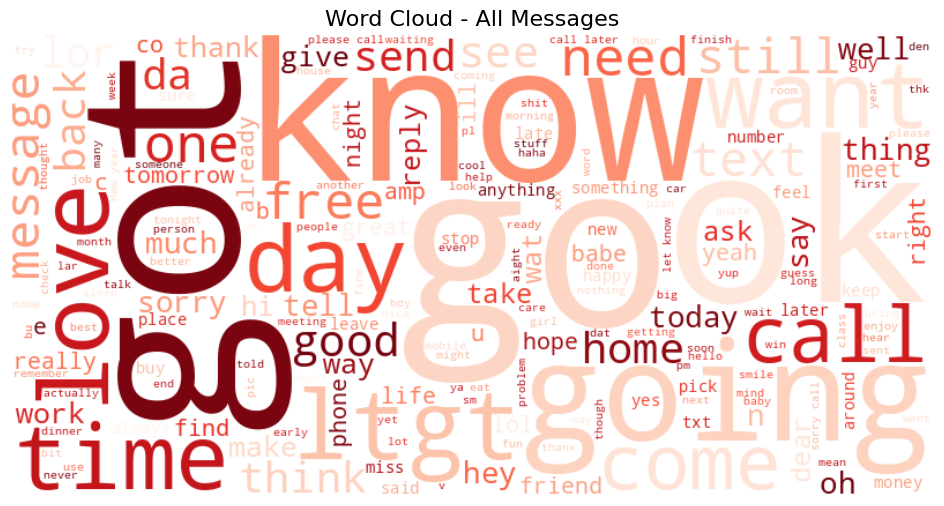

In [10]:
# Word Cloud of all cleaned messages
all_words = ' '.join(df['cleaned_message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - All Messages", fontsize=16)
plt.show()

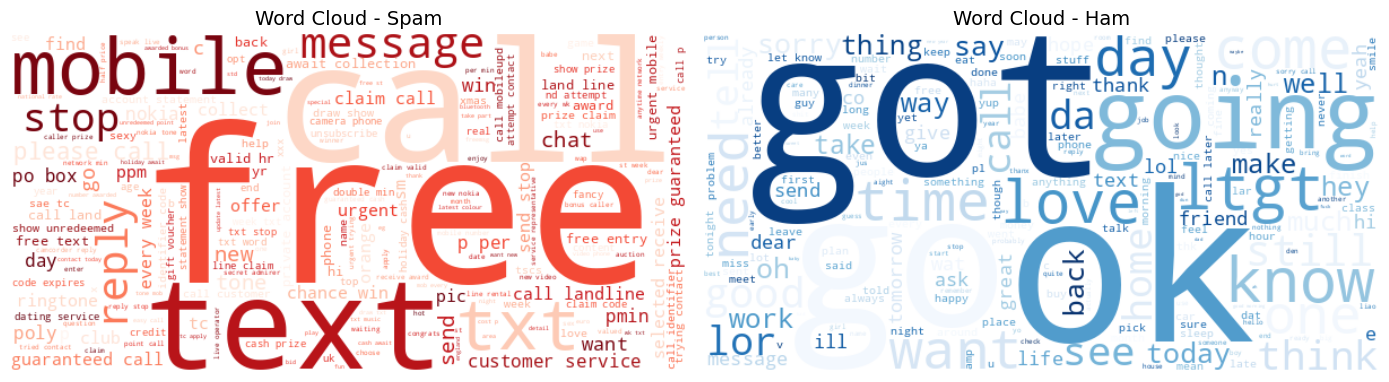

In [11]:
# Separate word clouds for Spam and Ham
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, title, cmap in zip(axes, [1, 0], ['Spam', 'Ham'], ['Reds', 'Blues']):
    text = ' '.join(df[df['label'] == label]['cleaned_message'])
    wc = WordCloud(width=600, height=300, background_color='white', colormap=cmap).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"Word Cloud - {title}", fontsize=14)

plt.tight_layout()
plt.show()

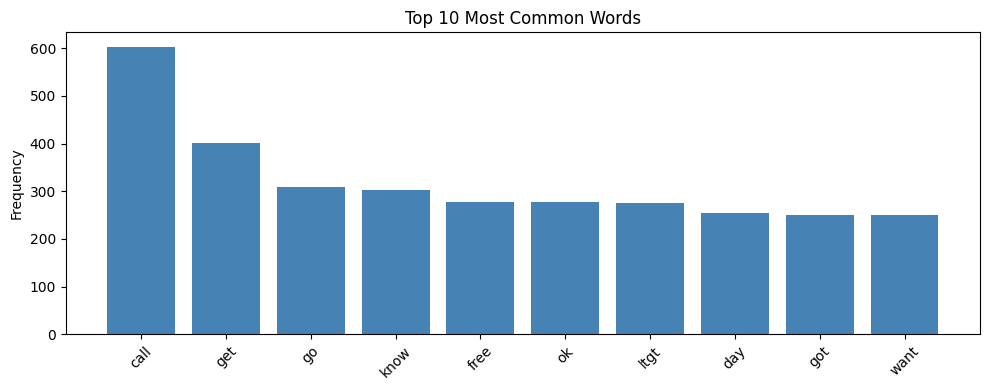

In [12]:
# Top 10 Most Common Words
words_list = all_words.split()
common_words = Counter(words_list).most_common(10)

words_labels = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure(figsize=(10, 4))
plt.bar(words_labels, counts, color='steelblue')
plt.title("Top 10 Most Common Words")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 8: Train-Test Split

In [13]:
X = df['cleaned_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


## Step 9: Tokenization and Percentile-Based Padding

In [14]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Percentile-based max length (avoids excessively long sequences)
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print("Max sequence length (95th percentile):", max_len)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

Max sequence length (95th percentile): 18
X_train_pad shape: (4457, 18)
X_test_pad shape: (1115, 18)
Vocabulary size: 6888


---
# Model 1: Simple RNN with Trainable Embedding

In [15]:
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9173 - loss: 0.2324 - val_accuracy: 0.9709 - val_loss: 0.1077
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9829 - loss: 0.0608 - val_accuracy: 0.9753 - val_loss: 0.0877
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9927 - loss: 0.0289 - val_accuracy: 0.9765 - val_loss: 0.0929
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9958 - loss: 0.0150 - val_accuracy: 0.9776 - val_loss: 0.1073


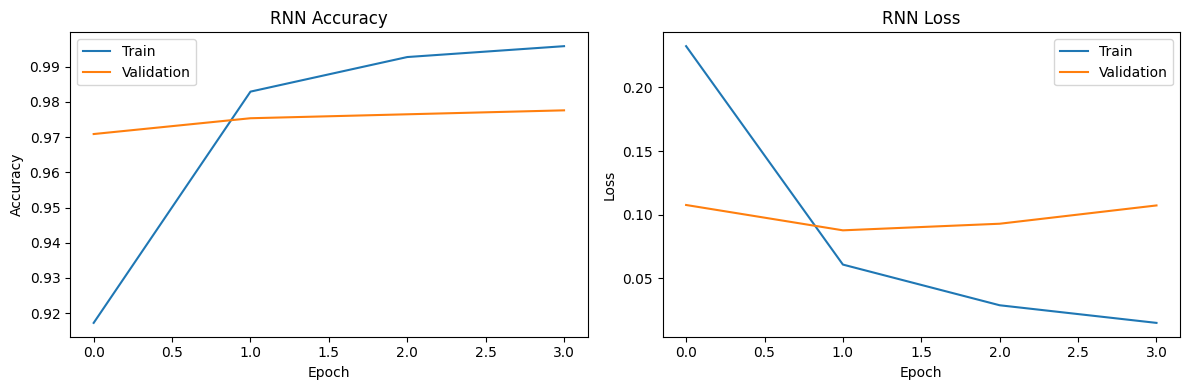

In [17]:
# RNN Accuracy and Loss Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_rnn.history['accuracy'], label='Train')
axes[0].plot(history_rnn.history['val_accuracy'], label='Validation')
axes[0].set_title('RNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rnn.history['loss'], label='Train')
axes[1].plot(history_rnn.history['val_loss'], label='Validation')
axes[1].set_title('RNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# RNN Evaluation
rnn_pred = (rnn_model.predict(X_test_pad) > 0.5).astype('int32')

print("=== RNN Confusion Matrix ===")
print(confusion_matrix(y_test, rnn_pred))

print("\n=== RNN Classification Report ===")
print(classification_report(y_test, rnn_pred, target_names=['Ham', 'Spam']))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
=== RNN Confusion Matrix ===
[[965   0]
 [ 29 121]]

=== RNN Classification Report ===
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       965
        Spam       1.00      0.81      0.89       150

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



---
# Model 2: LSTM with Trainable Embedding

In [19]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9072 - loss: 0.2488 - val_accuracy: 0.9709 - val_loss: 0.1058
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9846 - loss: 0.0579 - val_accuracy: 0.9753 - val_loss: 0.0770
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9935 - loss: 0.0228 - val_accuracy: 0.9787 - val_loss: 0.0804
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9964 - loss: 0.0110 - val_accuracy: 0.9753 - val_loss: 0.0972


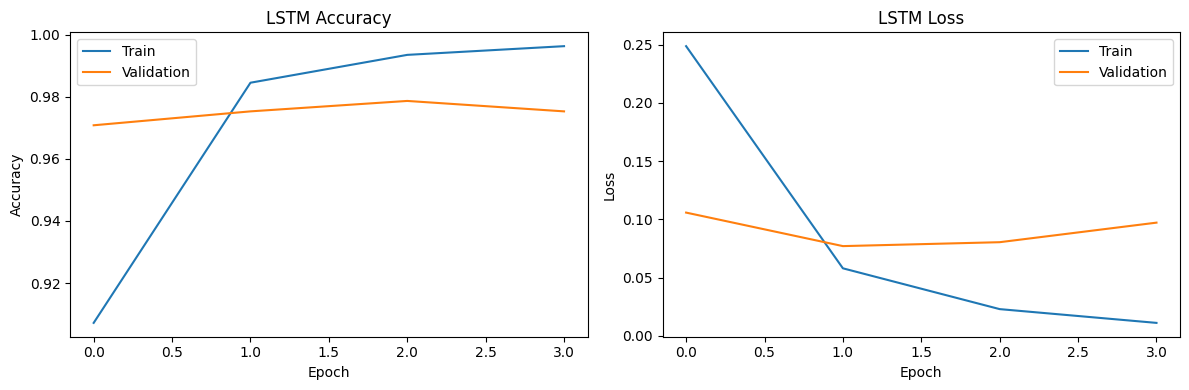

In [21]:
# LSTM Accuracy and Loss Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history['accuracy'], label='Train')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[0].set_title('LSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('LSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# LSTM Evaluation
lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype('int32')

print("=== LSTM Confusion Matrix ===")
print(confusion_matrix(y_test, lstm_pred))

print("\n=== LSTM Classification Report ===")
print(classification_report(y_test, lstm_pred, target_names=['Ham', 'Spam']))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
=== LSTM Confusion Matrix ===
[[963   2]
 [ 19 131]]

=== LSTM Classification Report ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.98      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



---
# Model 3: LSTM with Pretrained GloVe (Word2Vec) Embeddings

In [23]:
import gensim.downloader as api

# Load pretrained GloVe embeddings (50-dimensional)
print("Downloading GloVe embeddings... This may take a few minutes.")
embedding_model = api.load('glove-wiki-gigaword-50')
print("GloVe embeddings loaded successfully!")

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded successfully!


In [24]:
# Build Embedding Matrix
embedding_dim = 50  # must match glove-wiki-gigaword-50
word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim))

found = 0
for word, i in word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found += 1
        # Words not found remain as zeros

print(f"Words covered by GloVe: {found} / {min(len(word_index), vocab_size)}")

Words covered by GloVe: 5025 / 6887


In [25]:
# Build LSTM Model with Pretrained GloVe Embedding
lstm_glove_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False  # Freeze pretrained weights
    ),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_glove_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       344,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,400 (1.31 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 344,400 (1.31 MB)

In [26]:
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9195 - loss: 0.2333 - val_accuracy: 0.9484 - val_loss: 0.1648
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9602 - loss: 0.1165 - val_accuracy: 0.9484 - val_loss: 0.1448


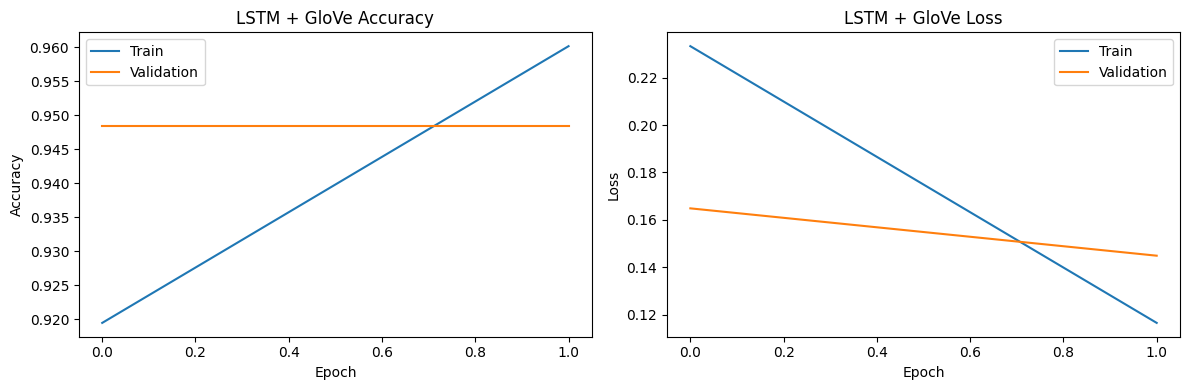

In [27]:
# GloVe LSTM Accuracy and Loss Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_glove.history['accuracy'], label='Train')
axes[0].plot(history_glove.history['val_accuracy'], label='Validation')
axes[0].set_title('LSTM + GloVe Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_glove.history['loss'], label='Train')
axes[1].plot(history_glove.history['val_loss'], label='Validation')
axes[1].set_title('LSTM + GloVe Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
# GloVe LSTM Evaluation
glove_pred = (lstm_glove_model.predict(X_test_pad) > 0.5).astype('int32')

print("=== LSTM + GloVe Confusion Matrix ===")
print(confusion_matrix(y_test, glove_pred))

print("\n=== LSTM + GloVe Classification Report ===")
print(classification_report(y_test, glove_pred, target_names=['Ham', 'Spam']))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
=== LSTM + GloVe Confusion Matrix ===
[[951  14]
 [ 39 111]]

=== LSTM + GloVe Classification Report ===
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.97       965
        Spam       0.89      0.74      0.81       150

    accuracy                           0.95      1115
   macro avg       0.92      0.86      0.89      1115
weighted avg       0.95      0.95      0.95      1115



---
# Final Comparison: Model 1 vs Model 2 vs Model 3

Model Comparison (Validation Accuracy):
  Model 1 - Simple RNN         : 0.9776
  Model 2 - LSTM               : 0.9787
  Model 3 - LSTM + GloVe       : 0.9484


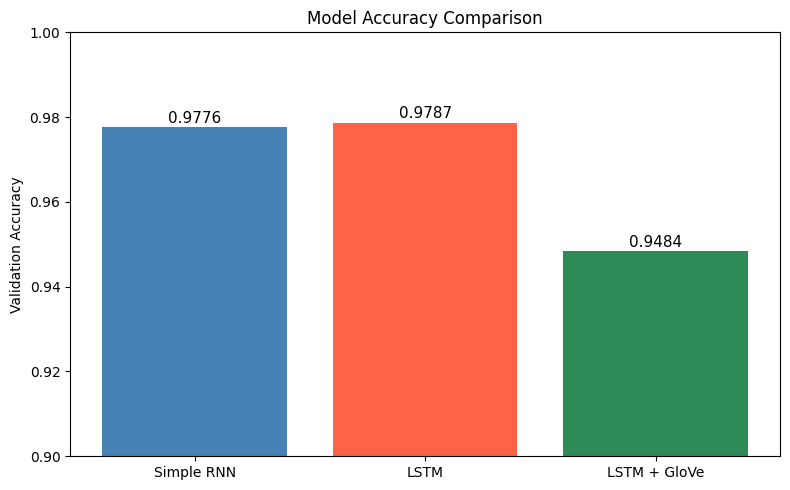

In [29]:
rnn_acc = max(history_rnn.history['val_accuracy'])
lstm_acc = max(history_lstm.history['val_accuracy'])
glove_acc = max(history_glove.history['val_accuracy'])

print("Model Comparison (Validation Accuracy):")
print(f"  Model 1 - Simple RNN         : {rnn_acc:.4f}")
print(f"  Model 2 - LSTM               : {lstm_acc:.4f}")
print(f"  Model 3 - LSTM + GloVe       : {glove_acc:.4f}")

# Bar chart comparison
models = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies = [rnn_acc, lstm_acc, glove_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'tomato', 'seagreen'])
plt.ylim(0.9, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Validation Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

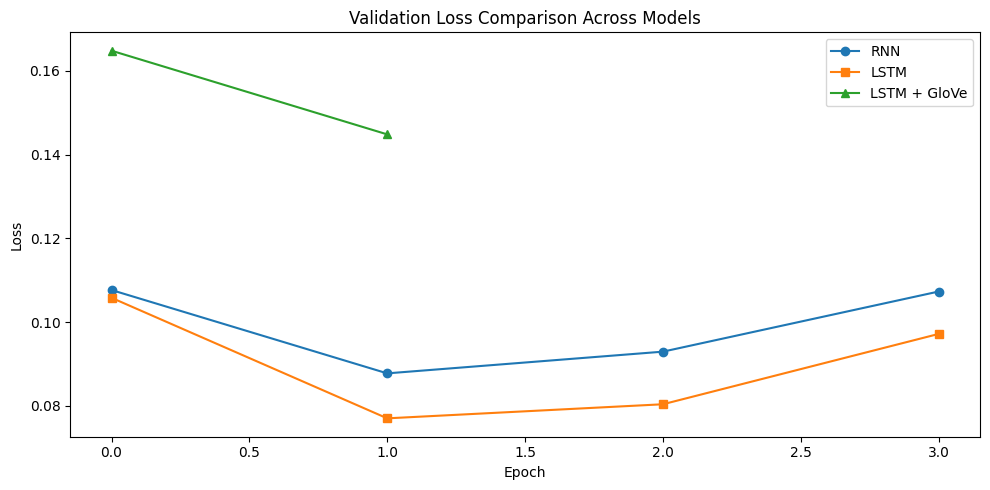

In [30]:
# Combined training loss comparison
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'], label='RNN', marker='o')
plt.plot(history_lstm.history['val_loss'], label='LSTM', marker='s')
plt.plot(history_glove.history['val_loss'], label='LSTM + GloVe', marker='^')
plt.title('Validation Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

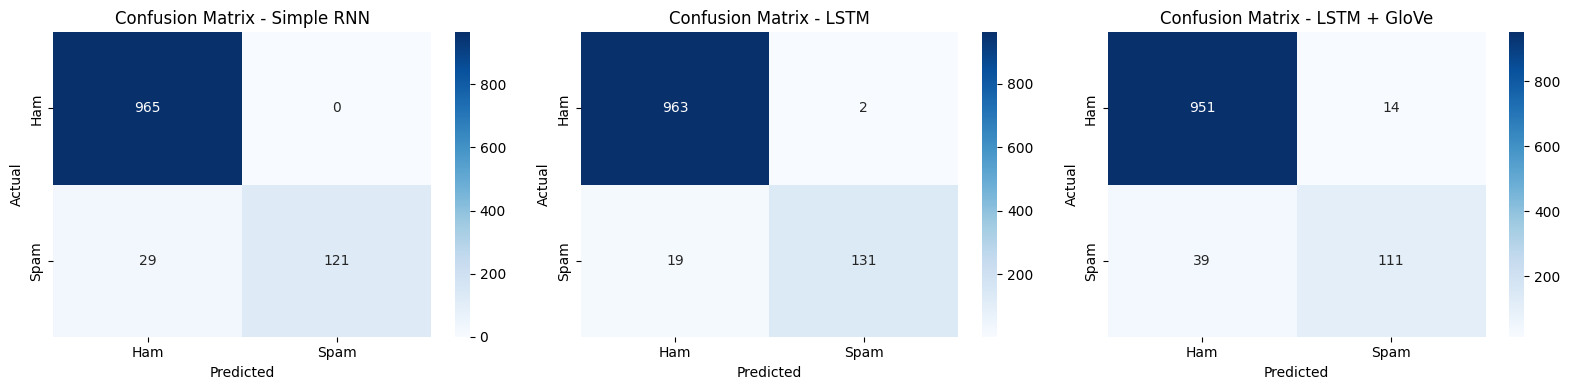

In [31]:
# Side-by-side Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, pred, title in zip(
    axes,
    [rnn_pred, lstm_pred, glove_pred],
    ['Simple RNN', 'LSTM', 'LSTM + GloVe']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
# Error Analysis

In [32]:
# Find misclassified examples from the best model (LSTM + GloVe)
X_test_list = X_test.reset_index(drop=True)
y_test_list = y_test.reset_index(drop=True)

misclassified = []
for i in range(len(y_test_list)):
    actual = y_test_list[i]
    predicted = glove_pred[i][0]
    if actual != predicted:
        misclassified.append({
            'Message': X_test_list[i],
            'Actual': 'Spam' if actual == 1 else 'Ham',
            'Predicted': 'Spam' if predicted == 1 else 'Ham'
        })

print(f"Total misclassified: {len(misclassified)}")
print("\n--- Sample Misclassified Examples ---\n")
for i, ex in enumerate(misclassified[:3]):
    print(f"Example {i+1}:")
    print(f"  Message   : {ex['Message']}")
    print(f"  Actual    : {ex['Actual']}")
    print(f"  Predicted : {ex['Predicted']}")
    print()

Total misclassified: 53

--- Sample Misclassified Examples ---

Example 1:
  Message   : know someone know fancy call find pobox lshb p
  Actual    : Spam
  Predicted : Ham

Example 2:
  Message   : per request maangalyam alaipayuthe set callertune caller press copy friend callertune
  Actual    : Ham
  Predicted : Spam

Example 3:
  Message   : k wen free come home also tel vikky hav sent mail also better come evening il free today aftr pm
  Actual    : Ham
  Predicted : Spam



---
# Real-Time Prediction

In [33]:
def predict_message(message, model=lstm_glove_model):
    cleaned = clean_text(message)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)
    prediction = model.predict(padded, verbose=0)[0][0]
    label = 'SPAM' if prediction > 0.5 else 'HAM'
    print(f"Message  : {message}")
    print(f"Cleaned  : {cleaned}")
    print(f"Result   : {label} (confidence: {prediction:.4f})")
    print()

# Test examples
predict_message("Congratulations! You've won a FREE iPhone. Click here to claim!")
predict_message("Hey, are you coming to the meeting tomorrow?")
predict_message("URGENT: Your account has been compromised. Call us now at 0800-FREE")

Message  : Congratulations! You've won a FREE iPhone. Click here to claim!
Cleaned  : congratulation free iphone click claim
Result   : HAM (confidence: 0.0912)

Message  : Hey, are you coming to the meeting tomorrow?
Cleaned  : hey coming meeting tomorrow
Result   : HAM (confidence: 0.0029)

Message  : URGENT: Your account has been compromised. Call us now at 0800-FREE
Cleaned  : urgent account compromised call u free
Result   : HAM (confidence: 0.0969)



In [34]:
# Install Gradio (if not installed)
!pip install gradio -q


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences



trained_model = lstm_model

def predict_tweet(tweet):

    try:

        # Clean text
        cleaned_text = clean_text(tweet)

        # Convert text to sequence
        sequence = tokenizer.texts_to_sequences([cleaned_text])

        # Padding
        padded_sequence = pad_sequences(
            sequence,
            maxlen=max_len
        )

        # Prediction
        prediction = trained_model.predict(padded_sequence)

        # Confidence score
        score = float(prediction[0][0])

        # Label
        if score >= 0.5:
            result = "Positive 😊"
        else:
            result = "Negative 😞"

        # Return output
        return (
            f"Prediction: {result}\n"
            f"Confidence Score: {score:.4f}"
        )

    except Exception as e:

        return f"Error: {str(e)}"


# ==========================================
# CREATE GUI
# ==========================================

gui = gr.Interface(
    fn=predict_tweet,

    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter your tweet here..."
    ),

    outputs="text",

    title="Tweet Sentiment Analysis System",

    description="Enter a tweet and get real-time prediction."
)


# ==========================================
# LAUNCH GUI
# ==========================================

gui.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b1cbad80bd14e6c917.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
